In [67]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns   
import plotly.express as px
import scipy.stats as stats

games_data = pd.read_csv('games.csv')

print(games_data.info) # verificar o tipo de dados de cada coluna
print()
print(games_data.head()) # verificar as primeiras linhas do DataFrame para entender a estrutura dos dados

<bound method DataFrame.info of                                 Name Platform  Year_of_Release         Genre  \
0                         Wii Sports      Wii           2006.0        Sports   
1                  Super Mario Bros.      NES           1985.0      Platform   
2                     Mario Kart Wii      Wii           2008.0        Racing   
3                  Wii Sports Resort      Wii           2009.0        Sports   
4           Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3           2016.0        Action   
16711               LMA Manager 2007     X360           2006.0        Sports   
16712        Haitaka no Psychedelica      PSV           2016.0     Adventure   
16713               Spirits & Spells      GBA           2003.0      Platform   
16714            Winning Post 8 2016      PSV           2016.0    Simulation   

       

In [68]:
#padronizar os nomes das colunas em minúsculas
games_data.columns = games_data.columns.str.lower()
print(games_data.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')


In [69]:
print(games_data.dtypes) #verificar os tipos de dados

name                   str
platform               str
year_of_release    float64
genre                  str
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score             str
rating                 str
dtype: object


In [70]:
#converter a coluna 'user_score' para numérico, tratando erros
games_data['user_score'] = pd.to_numeric(games_data['user_score'], errors='coerce') # converter para numérico, tratando erros

user_score Estava como str (string), mas deveria ser numérico (float), pois representa pontuações de usuários (ex.: "8.3", "8"). Isso pode causar problemas em operações matemáticas ou análises.

In [71]:
#tratamento de valores ausentes
print(games_data.isnull().sum()) # verificar a quantidade de valores ausentes em cada coluna

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [72]:
# Remover linhas com valores ausentes em 'name' e 'genre' (poucos casos)
games_data = games_data.dropna(subset=['name', 'genre'])

# Preencher 'year_of_release' com a mediana (para valores numéricos contínuos)
games_data['year_of_release'] = games_data['year_of_release'].fillna(games_data['year_of_release'].median())

# Para 'critic_score', 'user_score' e 'rating', deixar como NaN (não preencher, pois são muitos ausentes e subjetivos)
# user_score na conversão para numérico já tratou os erros, ja tratou o TBD

print(games_data.isnull().sum())

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64


In [73]:
# Calcular o total de vendas (soma das vendas em todas as regiões) para cada jogo
games_data['total_sales'] = (
    games_data['na_sales'] + 
    games_data['eu_sales'] + 
    games_data['jp_sales'] + 
    games_data['other_sales']
)

print(games_data[['name', 'total_sales']].head())

                       name  total_sales
0                Wii Sports        82.54
1         Super Mario Bros.        40.24
2            Mario Kart Wii        35.52
3         Wii Sports Resort        32.77
4  Pokemon Red/Pokemon Blue        31.38


Etapa 2: EDA

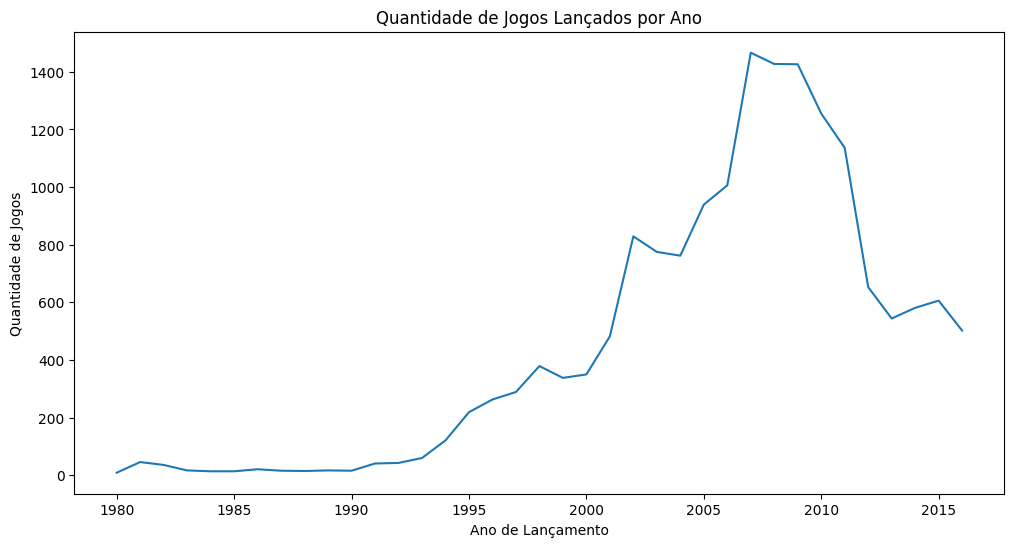

In [74]:
#agrupando os dados por ano de lançamento e contando o número de jogos lançados em cada ano
games_per_year = games_data.groupby('year_of_release')['name'].count().sort_index()

#visualizando a quantidade de jogos lançados por ano
plt.figure(figsize=(12, 6))
sns.lineplot(x=games_per_year.index, y=games_per_year.values)
plt.title('Quantidade de Jogos Lançados por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade de Jogos')
plt.show()

O mercado de jogos cresceu consistentemente até 2007, impulsionado por inovações em consoles. O pico marca o auge da era dos consoles tradicionais, seguido de uma queda brusca devido a mudanças na indústria (ex.: jogos digitais, mobile).

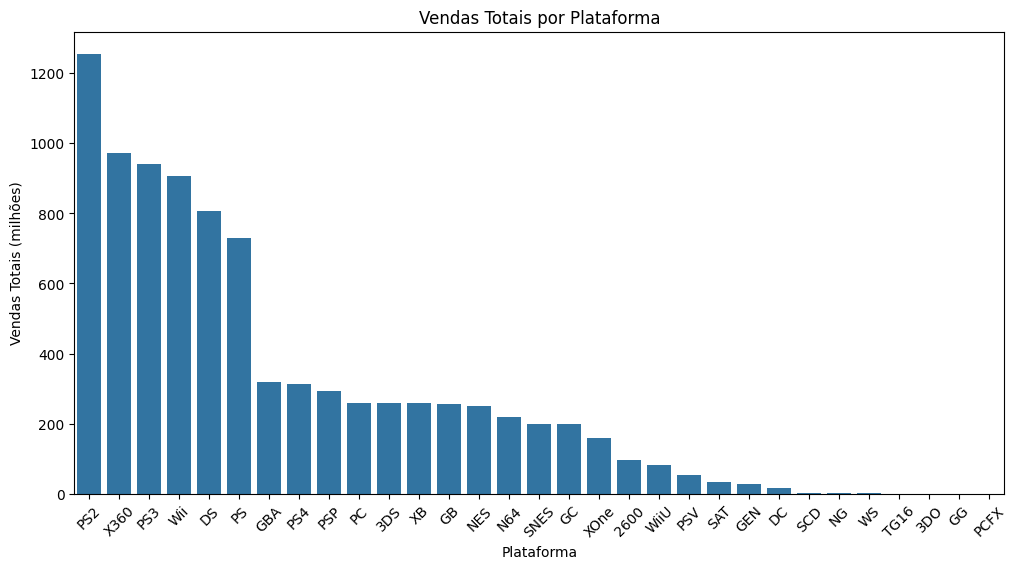

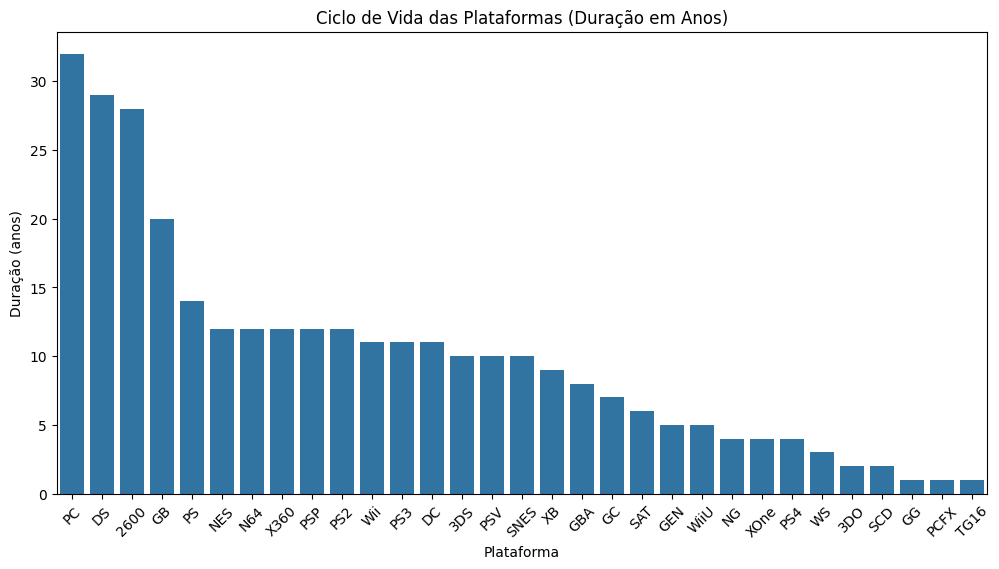

In [75]:
#calculando as vendas totais por plataforma e ano(historico completo)
sales_by_platform_year = games_data.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

#indenficando as plataformas com maiores volumes totais de vendas
total_sales_by_platform = games_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

#gráfico de barras para visualizar as vendas totais por plataforma
plt.figure(figsize=(12, 6))
sns.barplot(x=total_sales_by_platform.index, y=total_sales_by_platform.values)
plt.title('Vendas Totais por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Totais (milhões)')
plt.xticks(rotation=45)
plt.show()

#construindo uma distribuição anual de vendas por plataforma
all_sales_pivot = sales_by_platform_year.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)

# Análise do ciclo de vida das plataformas
platform_lifecycles = []
for platform in all_sales_pivot.columns:
    sales_for_platform = all_sales_pivot[platform]
    if (sales_for_platform > 0).any():
        first_year = sales_for_platform[sales_for_platform > 0].index.min()
        last_year = sales_for_platform[sales_for_platform > 0].index.max()
        lifespan = last_year - first_year + 1  # Incluindo o ano inicial
        platform_lifecycles.append({
            'Plataforma': platform,
            'Primeiro Ano': int(first_year),
            'Último Ano': int(last_year),
            'Duração (anos)': lifespan
        })

lifecycles_df = pd.DataFrame(platform_lifecycles)

#gráfico de barras para visualizar o ciclo de vida das plataformas
plt.figure(figsize=(12, 6))
sns.barplot(x='Plataforma', y='Duração (anos)', data=lifecycles_df.sort_values('Duração (anos)', ascending=False))
plt.title('Ciclo de Vida das Plataformas (Duração em Anos)')
plt.xlabel('Plataforma')
plt.ylabel('Duração (anos)')
plt.xticks(rotation=45)
plt.show()

As plataformas apresentam um ciclo médio de vida comercial entre 5 e 10 ano. Após esse período, observa-se declínio progressivo devido à transição para novas gerações.

In [76]:
# Filtrar dados para 2012-2016
recent_data = games_data[(games_data['year_of_release'] >= 2012) & (games_data['year_of_release'] <= 2016)]

# Plataformas ativas em 2016 (com vendas >0)
active_2016 = all_sales_pivot[all_sales_pivot.index == 2016.0].sum() > 0
active_platforms_2016 = active_2016[active_2016].index.tolist()
print("Plataformas ativas em 2016:", active_platforms_2016)

# Filtrar dados recentes para essas plataformas
recent_data = recent_data[recent_data['platform'].isin(active_platforms_2016)]

print(recent_data.head())
print(f"Número de jogos no período: {len(recent_data)}")

# Análise básica do mercado atual
recent_sales = recent_data.groupby('year_of_release')['total_sales'].sum()
print("Vendas totais por ano (2012-2016):")
print(recent_sales)

Plataformas ativas em 2016: ['3DS', 'PC', 'PS3', 'PS4', 'PSV', 'Wii', 'WiiU', 'X360', 'XOne']
                          name platform  year_of_release         genre  \
16          Grand Theft Auto V      PS3           2013.0        Action   
23          Grand Theft Auto V     X360           2013.0        Action   
31   Call of Duty: Black Ops 3      PS4           2015.0       Shooter   
33         Pokemon X/Pokemon Y      3DS           2013.0  Role-Playing   
34  Call of Duty: Black Ops II      PS3           2012.0       Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
16      7.02      9.09      0.98         3.96          97.0         8.2   
23      9.66      5.14      0.06         1.41          97.0         8.1   
31      6.03      5.86      0.36         2.38           NaN         NaN   
33      5.28      4.19      4.35         0.78           NaN         NaN   
34      4.99      5.73      0.65         2.42          83.0         5.3   

   rating 

In [77]:
#filtrando os dados para o período de 2012 a 2016 e plataformas ativas em 2016
recent_data = games_data[(games_data['year_of_release'] >= 2012) & (games_data['year_of_release'] <= 2016)]

#agregação de vendas totais por plataforma no período recente
recent_sales_by_platform = recent_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

#pivot para visualizar a distribuição de vendas por plataforma no período recente
recent_sales_pivot = recent_data.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').fillna(0)
print("Distribuição de vendas por plataforma (2012-2016):")
print()
print(recent_sales_pivot)   

Distribuição de vendas por plataforma (2012-2016):

platform           3DS     DS     PC     PS3     PS4   PSP    PSV    Wii  \
year_of_release                                                            
2012.0           51.36  11.01  23.22  107.36    0.00  7.69  16.19  21.71   
2013.0           56.57   1.54  12.38  113.25   25.99  3.14  10.59   8.59   
2014.0           43.76   0.00  13.28   47.76  100.00  0.24  11.90   3.75   
2015.0           27.78   0.00   8.52   16.82  118.90  0.12   6.25   1.14   
2016.0           15.14   0.00   5.25    3.60   69.25  0.00   4.25   0.18   

platform          WiiU   X360   XOne  
year_of_release                       
2012.0           17.56  99.74   0.00  
2013.0           21.65  88.58  18.96  
2014.0           22.03  34.74  54.07  
2015.0           16.35  11.96  60.14  
2016.0            4.60   1.52  26.15  


In [78]:
#calculando as vendas totais por plataforma no ano de (2012-2016)
sales_by_platform_year_recent = recent_data.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

#comparando a evolução ano a ano das vendas por plataforma no período recente
sales_by_platform_year_recent = px.histogram(sales_by_platform_year_recent, x='year_of_release', y='total_sales', color='platform', title='Evolução das Vendas por Plataforma (2012-2016)')
sales_by_platform_year_recent.show()

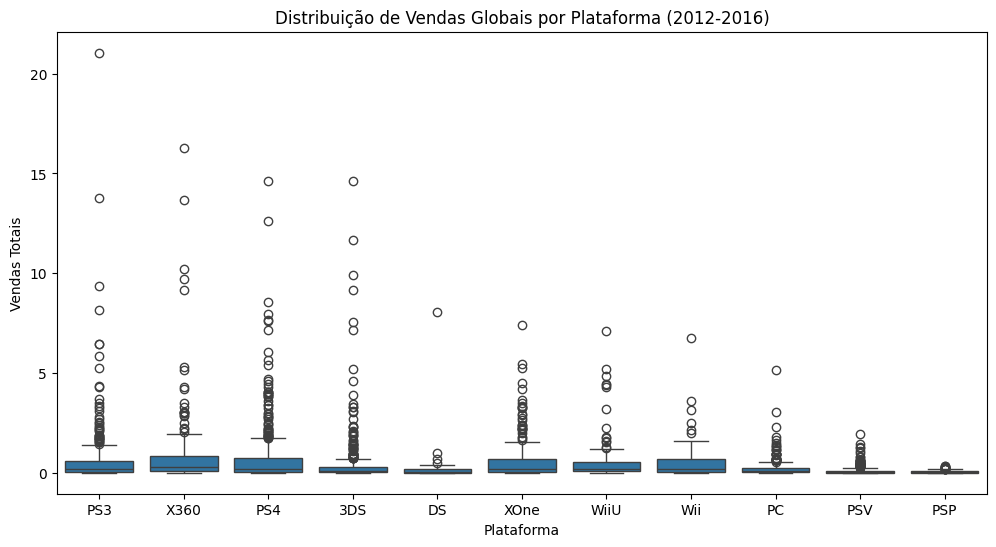

Vendas médias por plataforma (2012-2016):
platform
X360    0.810068
PS4     0.801378
Wii     0.655000
XOne    0.645020
PS3     0.585781
WiiU    0.559116
3DS     0.491439
DS      0.404839
PC      0.250600
PSV     0.119659
PSP     0.064682
Name: total_sales, dtype: float64


In [79]:
#construindo um diagrama de caixa para as vendas globais dividindo por plataforma
plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='total_sales', data=recent_data)
plt.title('Distribuição de Vendas Globais por Plataforma (2012-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Totais')
plt.show()

#calculando as vendas medias por plataforma no período recente
average_sales_by_platform_recent = recent_data.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
print("Vendas médias por plataforma (2012-2016):")
print(average_sales_by_platform_recent)

Entre 2012 e 2016, X360 e PS4 apresentaram as maiores médias de vendas por jogo, indicando forte desempenho comercial por título. No entanto, o X360 já estava em fase de transição, enquanto o PS4 se encontrava em expansão. Assim, o PS4 e o XOne demonstram maior potencial de continuidade para 2017.


Correlação entre critic_score e total_sales para PS4: 0.41
Correlação entre user_score e total_sales para PS4: -0.03


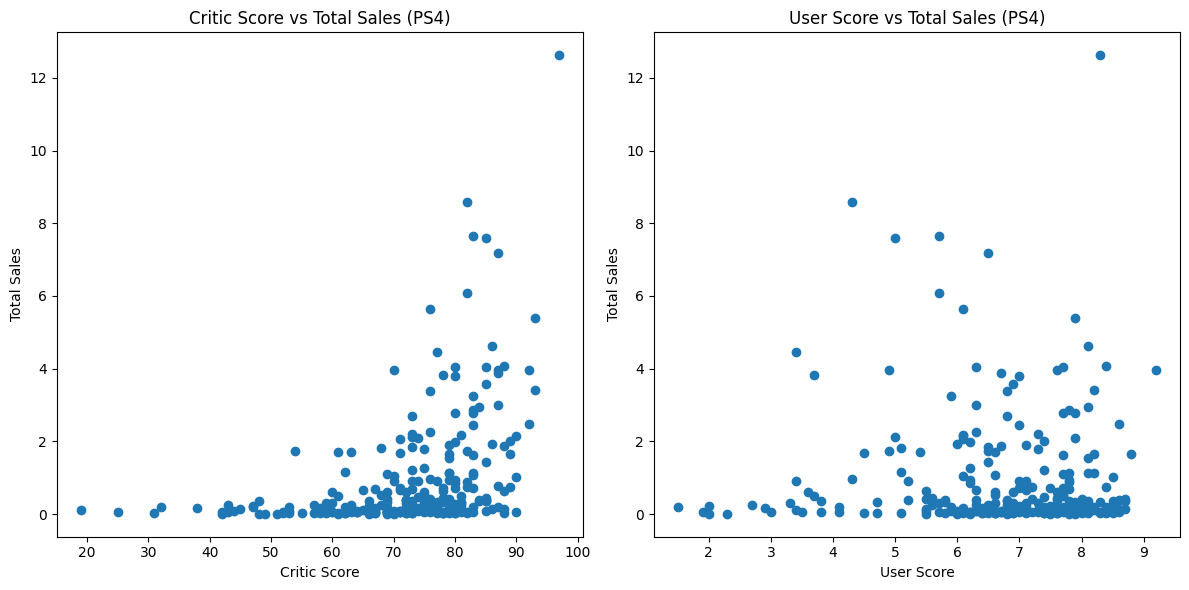

In [80]:
#escolhendo um plataforma (PS4)
ps4_data = recent_data[recent_data['platform'] == 'PS4']

#calculando a correlação critic_score e o total de vendas
correlation = ps4_data['critic_score'].corr(ps4_data['total_sales'])
print(f"Correlação entre critic_score e total_sales para PS4: {correlation:.2f}")

#calculando a correlação user_score e o total de vendas
correlation_user = ps4_data['user_score'].corr(ps4_data['total_sales'])
print(f"Correlação entre user_score e total_sales para PS4: {correlation_user:.2f}")

#gráfico de dispersão para critic_score vs total_sales e user_score vs total_sales para PS4
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'])
plt.xlabel('Critic Score')
plt.ylabel('Total Sales')
plt.title('Critic Score vs Total Sales (PS4)')

plt.subplot(1, 2, 2)
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'])
plt.xlabel('User Score')
plt.ylabel('Total Sales')
plt.title('User Score vs Total Sales (PS4)')

plt.tight_layout()
plt.show()



Para o PS4, observa-se uma correlação moderada (0,41) entre avaliações da crítica e vendas, enquanto a relação com avaliações dos usuários é praticamente inexistente (-0,03). Isso indica que a recepção crítica apresenta maior associação com o desempenho comercial, embora não seja um fator determinante isolado.

In [81]:
#calculando os jogos em diferentes plataformas
games_per_platform = games_data.groupby('platform')['name'].count().sort_values(ascending=False)

#filtrando o jogo 
gta = game_filtered = games_data[games_data['name'] == 'Grand Theft Auto V']

#comparando a venda do jogo em diferentes plataformas
gta_sales_by_platform = gta.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Vendas de Grand Theft Auto V por plataforma:")
print(gta_sales_by_platform)

print() 

#media de vendas por plataforma gta
games_per_platform = gta_sales_by_platform.mean()
print(f"Vendas médias de Grand Theft Auto V por plataforma: {games_per_platform:.2f}")


Vendas de Grand Theft Auto V por plataforma:
platform
PS3     21.05
X360    16.27
PS4     12.62
XOne     5.47
PC       1.17
Name: total_sales, dtype: float64

Vendas médias de Grand Theft Auto V por plataforma: 11.32


As vendas de **Grand Theft Auto V** variam significativamente entre plataformas, com maior concentração na geração PS3 e X360. Isso evidencia que o sucesso comercial de um jogo multiplataforma está diretamente associado à base instalada e ao estágio do ciclo de vida da plataforma no momento do lançamento. Plataformas com ecossistemas consolidados tendem a capturar maior volume de vendas.

**Distribuição de jogos por generos**

jogos por gênero:
genre
Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
Name: count, dtype: int64

vendas totais por gênero:
genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64

média de vendas por gênero:
genre
Platform        0.932173
Shooter         0.795503
Role-Playing    0.623872
Racing          0.583403
Sports          0.566980
Fighting        0.527126
Action          0.517711
Misc            0.458577
Simulation      0.446701
Puzzle          0.418224
Strategy        0.255095
Adventure       0.182341
Name: to

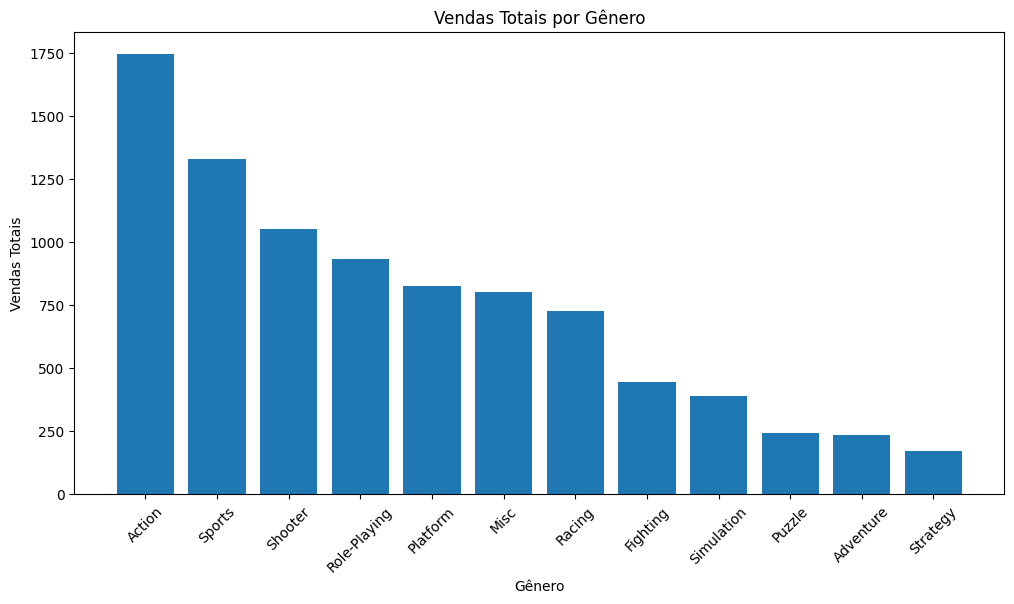

In [82]:
#contando os jogos por gêneros
games_per_genre = games_data['genre'].value_counts()
print(f'jogos por gênero:\n{games_per_genre}')
print()

#calculando as vendas totais por gênero
sales_by_genre = games_data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(f'vendas totais por gênero:\n{sales_by_genre}')
print()

#calculando a media de vendas por gênero
average_sales_by_genre = games_data.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print(f'média de vendas por gênero:\n{average_sales_by_genre}')

#criando um gráfico de barras para visualizar as vendas totais por gênero
plt.figure(figsize=(12, 6))
plt.bar(sales_by_genre.index, sales_by_genre.values)
plt.xlabel('Gênero')
plt.ylabel('Vendas Totais')
plt.title('Vendas Totais por Gênero')
plt.xticks(rotation=45)
plt.show()


Os dados indicam que gêneros como Action, Sports e Shooter concentram maior receita total, refletindo ampla aceitação de mercado e alto volume de lançamentos. Em contrapartida, gêneros como Strategy e Puzzle apresentam vendas significativamente menores, sugerindo perfil de nicho e menor escala comercial. Observa-se que a receita total tende a estar positivamente associada à quantidade de jogos lançados, indicando que popularidade produtiva influencia diretamente o desempenho agregado do gênero.

É possível generalizar que gêneros de apelo amplo concentram maior receita total, enquanto gêneros de nicho apresentam menor escala comercial. No entanto, o desempenho individual de um jogo depende de múltiplos fatores além do gênero, e a lucratividade agregada está parcialmente associada ao volume de lançamentos dentro de cada categoria.

**Criando um perfil de usuário**

In [83]:
#determinando as cincos plataformas principais para região AN, UE e JP
top_platforms_an = games_data.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_platforms_eu = games_data.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_platforms_jp = games_data.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 plataformas na América do Norte:")
print(top_platforms_an)
print("\nTop 5 plataformas na União Europeia:")
print(top_platforms_eu)
print("\nTop 5 plataformas no Japão:")
print(top_platforms_jp)


Top 5 plataformas na América do Norte:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas na União Europeia:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas no Japão:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


As quotas de mercado variam significativamente entre regiões, refletindo diferenças culturais, preferência por marcas e estrutura do mercado. América do Norte favorece consoles da Microsoft e gêneros competitivos, Europa demonstra maior alinhamento com a Sony, enquanto o Japão apresenta forte preferência por portátei


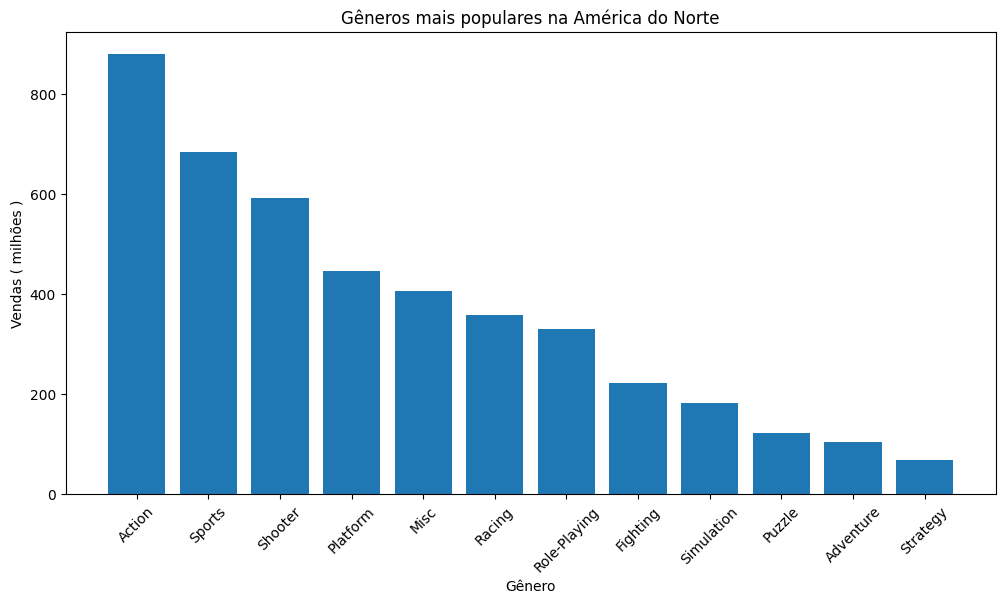

In [84]:
#calculando as vendas totais por genêro e região
genre_sales_jp = games_data.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
genre_sales_eu = games_data.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
genre_sales_na = games_data.groupby('genre')['na_sales'].sum().sort_values(ascending=False) 

#analisarndo os gêneros mais populares na América do Norte
plt.figure(figsize=(12, 6))
plt.bar(range(len(genre_sales_na)), genre_sales_na.values)
plt.xticks(range(len(genre_sales_na)), genre_sales_na.index, rotation=45)
plt.title('Gêneros mais populares na América do Norte')
plt.xlabel('Gênero')
plt.ylabel('Vendas ( milhões )')
plt.show()

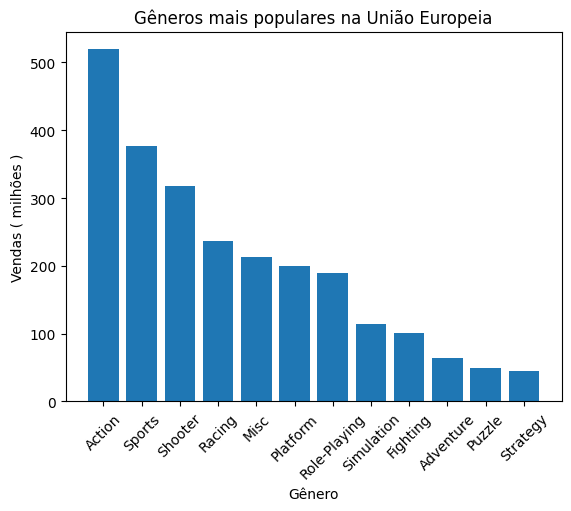

In [85]:
#comparando os gêneros mais populares na União Europeia
plt.bar(range(len(genre_sales_eu)), genre_sales_eu.values)
plt.xticks(range(len(genre_sales_eu)), genre_sales_eu.index, rotation=45)
plt.title('Gêneros mais populares na União Europeia')
plt.xlabel('Gênero')
plt.ylabel('Vendas ( milhões )')
plt.show()


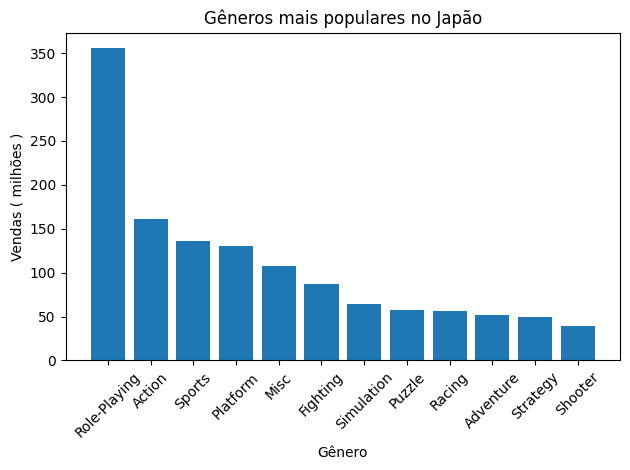

In [86]:
#analisando os gêneros mais populares no Japão
plt.bar(range(len(genre_sales_jp)), genre_sales_jp.values)
plt.xticks(range(len(genre_sales_jp)), genre_sales_jp.index, rotation=45)
plt.title('Gêneros mais populares no Japão')
plt.xlabel('Gênero')
plt.ylabel('Vendas ( milhões )')
plt.tight_layout()
plt.show()

Action é o gênero dominante globalmente, liderando na América do Norte e Europa. No entanto, o Japão apresenta um padrão distinto, com forte predominância de Role-Playing. Shooter demonstra forte popularidade apenas no Ocidente, enquanto RPG é significativamente mais relevante no mercado japonês. Essas diferenças refletem fatores culturais, históricos e estruturais específicos de cada região.

**classificações do ESRB**

In [87]:
#analisando vendas por classificação em cada região
vendas_por_rating = games_data.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum().sort_values(by='na_sales', ascending=False)
print(vendas_por_rating)

        na_sales  eu_sales  jp_sales
rating                              
E        1292.99    710.25    198.11
T         759.75    427.03    151.40
M         748.48    483.97     64.24
E10+      353.32    188.52     40.20
K-A         2.56      0.27      1.46
EC          1.53      0.11      0.00
AO          1.26      0.61      0.00
RP          0.00      0.08      0.00


In [88]:
#calculando o percentual de cada classificação por região
percent_regiao_na = (vendas_por_rating['na_sales'] / vendas_por_rating['na_sales'].sum()) * 100
percent_regiao_eu = (vendas_por_rating['eu_sales'] / vendas_por_rating['eu_sales'].sum()) * 100
percent_regiao_jp = (vendas_por_rating['jp_sales'] / vendas_por_rating['jp_sales'].sum()) * 100
print("Percentual de vendas por classificação na América do Norte:")
print(percent_regiao_na)
print("Percentual de vendas por classificação na União Europeia:")
print(percent_regiao_eu)
print("Percentual de vendas por classificação no Japão:")
print(percent_regiao_jp)

Percentual de vendas por classificação na América do Norte:
rating
E       40.918829
T       24.043558
M       23.686900
E10+    11.181402
K-A      0.081015
EC       0.048419
AO       0.039875
RP       0.000000
Name: na_sales, dtype: float64
Percentual de vendas por classificação na União Europeia:
rating
E       39.222129
T       23.581874
M       26.726271
E10+    10.410638
K-A      0.014910
EC       0.006075
AO       0.033686
RP       0.004418
Name: eu_sales, dtype: float64
Percentual de vendas por classificação no Japão:
rating
E       43.501460
T       33.244768
M       14.105970
E10+     8.827211
K-A      0.320590
EC       0.000000
AO       0.000000
RP       0.000000
Name: jp_sales, dtype: float64


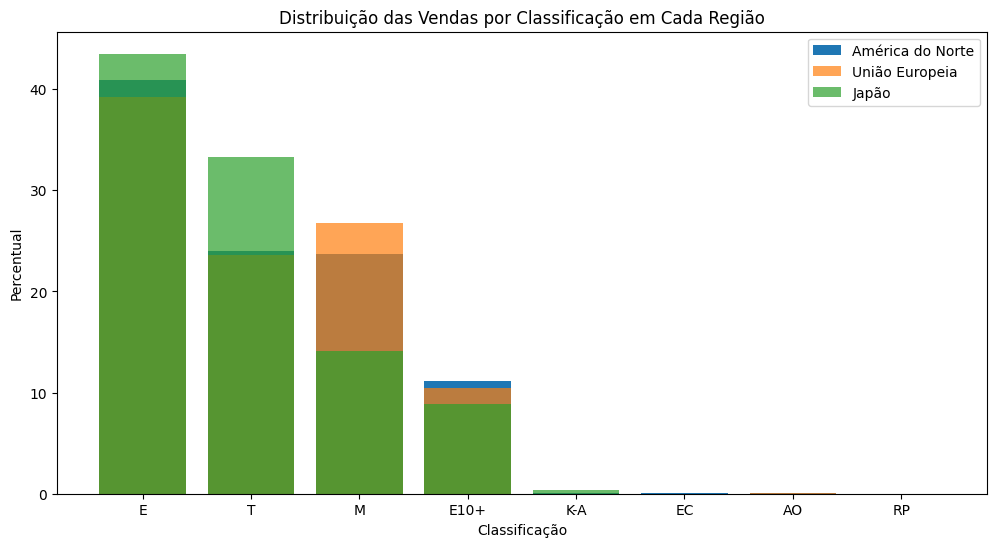

In [89]:
#comparando as diferenças regionais nas classificações
plt.figure(figsize=(12, 6))
plt.bar(percent_regiao_na.index, percent_regiao_na.values, label='América do Norte')
plt.bar(percent_regiao_eu.index, percent_regiao_eu.values, label='União Europeia', alpha=0.7)
plt.bar(percent_regiao_jp.index, percent_regiao_jp.values, label='Japão', alpha=0.7)
plt.xlabel('Classificação')
plt.ylabel('Percentual')
plt.title('Distribuição das Vendas por Classificação em Cada Região')
plt.legend()
plt.show()


A classificação ESRB exerce influência diferenciada entre regiões. Enquanto mercados ocidentais demonstram alta aceitação de títulos classificados como Mature, o mercado japonês apresenta maior concentração em classificações voltadas a públicos amplos, sugerindo influência cultural sobre o padrão de consumo. Entretanto, a classificação isoladamente não determina o sucesso comercial, devendo ser analisada em conjunto com gênero, plataforma e contexto regional.

**TESTE DE HIPOTESE**


In [90]:
#Filtrando os dados de xbox one e pc
xbox_one_score = games_data[games_data['platform'] == 'XOne']['user_score']
pc_score = games_data[games_data['platform'] == 'PC']['user_score']

#analise exploratória
print("User Score para Xbox One:", xbox_one_score.mean())
print("xbox one - tamanho da amostra:", len(xbox_one_score))
print("User Score para PC:", pc_score.mean())
print("PC - tamanho da amostra:", len(pc_score))


User Score para Xbox One: 6.521428571428572
xbox one - tamanho da amostra: 247
User Score para PC: 7.062467532467533
PC - tamanho da amostra: 974


In [91]:
# Teste t para duas amostras independentes
t_statistic, p_value = stats.ttest_ind(xbox_one_score.dropna(), pc_score.dropna(), equal_var=False)
print(f"Teste t: t_statistic = {t_statistic:.2f}, p_value = {p_value:.4f}")

#interpretação do teste t
alpha = 0.05 #definindo o nível de significância

if p_value < alpha:
    print("Rejeitamos a hipótese nula: há uma diferença significativa entre as médias de user_score para Xbox One e PC.")
else:
    print("Não rejeitamos a hipótese nula: não há evidências suficientes para afirmar que há uma diferença significativa entre as médias de user_score para Xbox One e PC.")

Teste t: t_statistic = -4.65, p_value = 0.0000
Rejeitamos a hipótese nula: há uma diferença significativa entre as médias de user_score para Xbox One e PC.


O teste t indica diferença estatisticamente significativa entre as médias de avaliações dos usuários para Xbox One e PC (p < 0,05). Portanto, rejeita-se a hipótese de igualdade das médias. Contudo, a magnitude da diferença deve ser analisada para avaliar sua relevância prática no contexto do mercado.

In [92]:
#filtrando dados para os generos de ação e esportes
action_score = games_data[games_data['genre'] == 'Action']['user_score']
sports_score = games_data[games_data['genre'] == 'Sports']['user_score']

#analise exploratória
print("User Score para Action:", action_score.mean())
print("Action - tamanho da amostra:", len(action_score))
print("User Score para Sports:", sports_score.mean())
print("Sports - tamanho da amostra:", len(sports_score))

User Score para Action: 7.054043715846995
Action - tamanho da amostra: 3369
User Score para Sports: 6.96119673617407
Sports - tamanho da amostra: 2348


In [93]:
#teste t para duas amostras independentes
t_statistic_genre, p_value_genre = stats.ttest_ind(action_score.dropna(), sports_score.dropna(), equal_var=False)
print(f"Teste t: t_statistic = {t_statistic_genre:.2f}, p_value = {p_value_genre:.4f}")

#interpretação do teste t

alpha = 0.05 #definindo o nível de significância

if p_value_genre < alpha:
    print("Rejeitamos a hipótese nula: há uma diferença significativa entre as médias de user_score para os gêneros Action e Sports.")
else:
    print("Não rejeitamos a hipótese nula: não há evidências suficientes para afirmar que há uma diferença significativa entre as médias de user_score para os gêneros Action e Sports.")

Teste t: t_statistic = 1.58, p_value = 0.1148
Não rejeitamos a hipótese nula: não há evidências suficientes para afirmar que há uma diferença significativa entre as médias de user_score para os gêneros Action e Sports.


O teste t não identificou diferença estatisticamente significativa entre as médias de avaliações de usuários para os gêneros Action e Sports (p = 0,1148). Assim, não há evidência suficiente para afirmar que os dois gêneros apresentam médias distintas de avaliação pelos usuários no nível de significância adotado.

As hipóteses foram formuladas considerando um teste t bilateral para comparação de médias entre dois grupos independentes. A hipótese nula assumiu igualdade entre as médias populacionais, enquanto a hipótese alternativa considerou a existência de diferença. Foi adotado nível de significância de 5% (α = 0,05), padrão em análises estatísticas, representando uma probabilidade máxima de 5% de erro tipo I. A decisão foi baseada na comparação entre o p-valor obtido e o nível de significância estabelecido.